Import und Setup

In [1]:
# Install (falls nötig)
# pip install langgraph langchain langchain-openai neo4j

from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_community.graphs import Neo4jGraph

import os

API

In [ ]:
os.environ["OPENAI_API_KEY"] = ""

llm = ChatOpenAI(model="gpt-5.4-nano", temperature=0)

graph = Neo4jGraph(
    url="neo4j://localhost:7687",
    username="neo4j",
    password="chatwithgermany"
)

State

In [ ]:
from typing import TypedDict

class AgentState(TypedDict):
    # INPUT
    question: str  
    # User Question 

    # INTERPRETATION (durch LLM)
    intent: str  
    # Question Type:
    # - "within"  → Hierachy
    # - "touches" → Neighbourhood
    # - "relates"
    # → is used for routing in the grap
    
    entity_name: str  
    # Name of the entity

    source_type: str  
    # Starting Node in the Graph
    # Example: "City", "District", "AdministrativeDistrict", "FederalState"

    target_type: str  
    # End Node in the Graph
    # Important for:
    # - Direction
    # - Step Count

    direction: str  
    # - "up" District → FederalState)
    # - "down" FederalState → District)
    # → decides, which Query-Logic is used

    # QUERY GENERATION
    cypher_query: str  
    # Neo4j Cypher Query

    # OUTPUT
    result: str  

Hierarchy

In [ ]:
HIERARCHY = [
    "City",
    "District",
    "AdministrativeDistrict",
    "FederalState"
]

Normalizer

In [ ]:
def normalize(text: str):
    text = text.lower()

    mapping = {
        "city": "City",
        "stadt": "City",
        "städte": "City",

        "district": "District",
        "kreis": "District",
        "landkreis": "District",

        "regierungsbezirk": "AdministrativeDistrict",

        "bundesland": "FederalState",
        "bundesländer": "FederalState",
        "state": "FederalState"
    }

    for k, v in mapping.items():
        if k in text:
            return v

    return None

Parsing

In [ ]:
def safe_parse(response):
    import json
    try:
        data = json.loads(response)
    except:
        return {"intent": "within", "entity_name": ""}

    data.setdefault("intent", "within")
    data.setdefault("entity_name", "")

    return data

Interpret Query

In [ ]:
def interpret_query(state):
    prompt = f"""
Classify the question into one of these intents:

- "within": hierarchical containment (liegt in, gehört zu, in welchem Bundesland, welche Städte in ...)
- "touches": geographic neighbors (grenzt an)
- "relates": generic relation

Question:
{state['question']}

Return JSON:
{{
  "intent": "...",
  "entity_name": "..."
}}

Rules:
- "liegt in", "in welchem Bundesland" → ALWAYS "within"
- "welche Städte in ..." → ALWAYS "within"
- "grenzt an" → ALWAYS "touches"
"""

    response = llm.invoke(prompt).content
    parsed = safe_parse(response)

    return {
        **state,
        "intent": parsed["intent"],
        "entity_name": parsed["entity_name"]
    }

Entity Type Resolver

In [ ]:
def resolve_entity_type(state):
    query = """
    MATCH (n)
    WHERE toLower(n.Name) = toLower($name)
    RETURN labels(n)[0] AS type
    """

    results = graph.query(query, {"name": state["entity_name"]})

    if not results:
        return {**state, "source_type": "District"}  # fallback

    types = [r["type"] for r in results]

    intent = state["intent"]
    question = state["question"].lower()

    # 🎯 HEURISTIK

    # 1. Wenn nach Städten IN etwas gefragt wird → das "etwas" ist größer
    if intent == "within" and "cities" in question or "städte" in question:
        if "District" in types:
            return {**state, "source_type": "District"}

    # 2. Wenn "liegt in Bundesland" → Start ist klein → City bevorzugen
    if "bundesland" in question:
        if "City" in types:
            return {**state, "source_type": "City"}

    # 3. touches → gleiche Ebene → meist City sinnvoll
    if intent == "touches":
        if "City" in types:
            return {**state, "source_type": "City"}

    # 4. fallback: nimm die "größere Einheit"
    priority = ["City", "District", "AdministrativeDistrict", "FederalState"]

    for p in priority[::-1]:  # große zuerst
        if p in types:
            return {**state, "source_type": p}

    return {**state, "source_type": types[0]}

Target Type

In [ ]:
def resolve_target_type(state):
    question = state["question"].lower()

    # 1. detect from question
    detected = normalize(question)

    if detected:
        return {
            **state,
            "target_type": detected
        }

    # 2. fallback: move ONE level in hierarchy
    if state["intent"] == "within":
        source = state["source_type"]
        idx = HIERARCHY.index(source)

        if idx + 1 < len(HIERARCHY):
            return {
                **state,
                "target_type": HIERARCHY[idx + 1]
            }

    # 3. touches → same level
    if state["intent"] == "touches":
        return {
            **state,
            "target_type": state["source_type"]
        }

    # 4. final fallback
    return {
        **state,
        "target_type": "District"
    }

Direction


In [ ]:
def infer_direction(source, target):
    if source not in HIERARCHY or target not in HIERARCHY:
        return "down"  # safe fallback

    s = HIERARCHY.index(source)
    t = HIERARCHY.index(target)

    if s < t:
        return "down"
    if s > t:
        return "up"
    return "same"

In [ ]:
def add_direction(state):
    return {
        **state,
        "direction": infer_direction(
            state["source_type"],
            state["target_type"]
        )
    }

Routing

In [ ]:
def select_query_type(state):
    if state["intent"] == "within":
        return f"within_{state['direction']}"

    return f"{state['intent']}_action"

Within

In [ ]:
def build_within_up(state):
    source = state["source_type"]
    target = state["target_type"]
    name = state["entity_name"]

    start = HIERARCHY.index(source)
    end = HIERARCHY.index(target)

    query = f"MATCH (start:{source} {{Name: '{name}'}})"

    current = "start"

    for i in range(start, end):
        next_level = HIERARCHY[i + 1]

        next_var = f"n{i}"

        query += f"""
        MATCH ({current})
        -[:hasFootprint]->(:Geometry)
        -[:within]->(:Geometry)
        <-[:hasFootprint]-({next_var}:{next_level})
        """

        current = next_var

    query += f"\nRETURN {current}.Name AS result"

    return {**state, "cypher_query": query}

In [ ]:
def build_within_down(state):
    source = state["source_type"]
    target = state["target_type"]
    name = state["entity_name"]

    start = HIERARCHY.index(source)
    end = HIERARCHY.index(target)

    query = f"MATCH (start:{source} {{Name: '{name}'}})"

    current = "start"

    for i in range(start, end, -1):
        lower = HIERARCHY[i - 1]

        next_var = f"n{i}"

        query += f"""
        MATCH ({current})
        <-[:hasFootprint]-(:Geometry)
        <-[:within]-(:Geometry)
        -[:hasFootprint]->({next_var}:{lower})
        """

        current = next_var

    query += f"\nRETURN {current}.Name AS result"

    return {**state, "cypher_query": query}

touches

In [ ]:
def build_touches_query(state):
    return {
        **state,
        "cypher_query": f"""
        MATCH p=
        (:{state['source_type']} {{Name: '{state['entity_name']}'}})
        -[:hasFootprint]->(:Geometry)
        <-[:touches]-(:Geometry)
        <-[:hasFootprint]-(:{state['source_type']})
        RETURN p
        """
    }

relates

In [ ]:
def build_relates_query(state):
    return {
        **state,
        "cypher_query": f"""
        MATCH p=
        (:{state['source_type']} {{Name: '{state['entity_name']}'}})
        -[:relates]->(:{state['source_type']})
        RETURN p
        """
    }

execute query

In [ ]:
def execute_query(state):
    result = graph.query(state["cypher_query"])

    cleaned = [r["result"] for r in result]

    return {**state, "result": cleaned}

answer

In [ ]:
def verbalize(state):
    prompt = f"""
Turn into natural German:

Question: {state['question']}
Result: {state['result']}
"""

    return {
        **state,
        "result": llm.invoke(prompt).content
    }

build graph

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("interpret_query", interpret_query)
workflow.add_node("resolve_entity_type", resolve_entity_type)
workflow.add_node("resolve_target_type", resolve_target_type)
workflow.add_node("add_direction", add_direction)

workflow.add_node("build_within_up", build_within_up)
workflow.add_node("build_within_down", build_within_down)
workflow.add_node("build_touches_query", build_touches_query)
workflow.add_node("build_relates_query", build_relates_query)

workflow.add_node("execute_query", execute_query)
workflow.add_node("verbalize", verbalize)

workflow.add_edge(START, "interpret_query")
workflow.add_edge("interpret_query", "resolve_entity_type")
workflow.add_edge("resolve_entity_type", "resolve_target_type")
workflow.add_edge("resolve_target_type", "add_direction")

workflow.add_conditional_edges(
    "add_direction",
    select_query_type,
    {
        "within_up": "build_within_up",
        "within_down": "build_within_down",
        "touches_action": "build_touches_query",
        "relates_action": "build_relates_query"
    }
)

workflow.add_edge("build_within_up", "execute_query")
workflow.add_edge("build_within_down", "execute_query")
workflow.add_edge("build_touches_query", "execute_query")
workflow.add_edge("build_relates_query", "execute_query")

workflow.add_edge("execute_query", "verbalize")
workflow.add_edge("verbalize", END)

compiled_graph = workflow.compile()

display graph

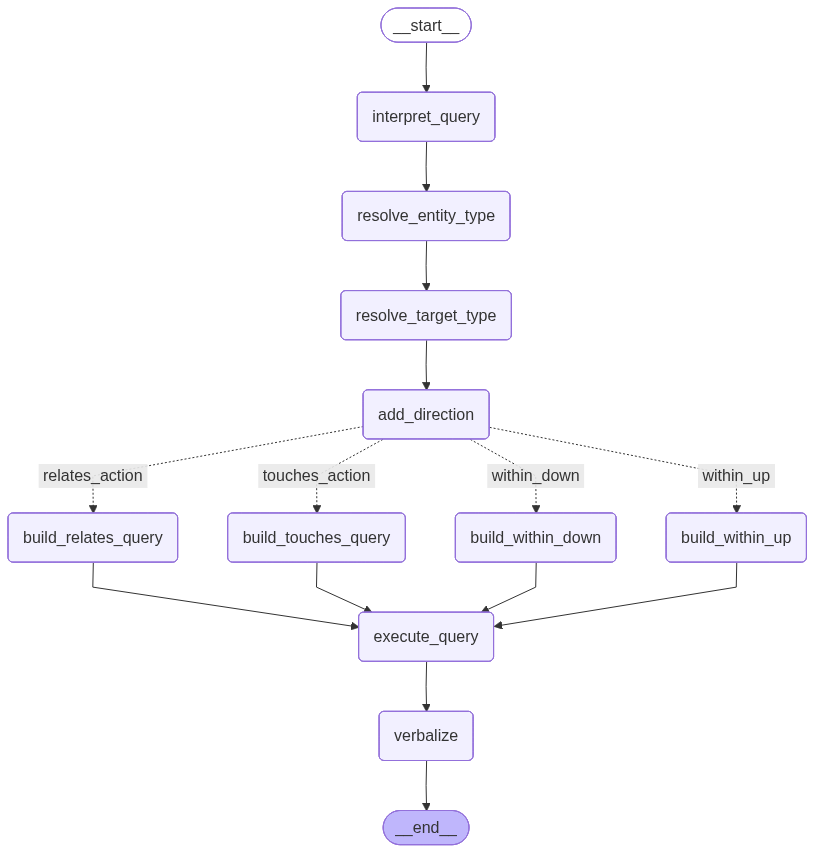

In [ ]:
from IPython.display import Image, display

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

testing

In [ ]:
compiled_graph.invoke({
    "question": "In welchem Bundesland liegt Siegburg?"
})

{'question': 'In welchem Bundesland liegt Siegburg?',
 'intent': 'within',
 'entity_name': 'Siegburg',
 'source_type': 'City',
 'target_type': 'FederalState',
 'direction': 'down',
 'cypher_query': "MATCH (start:City {Name: 'Siegburg'})\nRETURN start.Name AS result",
 'result': '**Frage:** In welchem Bundesland liegt Siegburg?  \n**Antwort:** Siegburg liegt im Bundesland **Nordrhein-Westfalen**.'}

In [ ]:
compiled_graph.invoke({
    "question": "What Cities lie in Borken?"
})

{'question': 'What Cities lie in Borken?',
 'intent': 'within',
 'entity_name': 'Borken',
 'source_type': 'District',
 'target_type': 'AdministrativeDistrict',
 'direction': 'down',
 'cypher_query': "MATCH (start:District {Name: 'Borken'})\nRETURN start.Name AS result",
 'result': 'Welche Städte liegen in Borken?  \nAntwort: Borken'}

In [ ]:
compiled_graph.invoke({
    "question": "Welche Städte liegen an Siegburg?"
})

KeyError: 'within_same'